In [1]:
from ocotillopmf import PowerLawAccrete, PMF
import numpy as np
import scipy.integrate as sint
import matplotlib.pyplot as plt
import seaborn as sne

In [2]:
#Define a tapered turbulent core model
#Can either pass (j, jf, m0) separately, like this, or define a tuple
#ike params = (j, jf, m0) and pass as *params.
plawObj = PowerLawAccrete(0.5, 0.75, 3.6E-5, deltan1 = 1.0)

In [3]:
#Define a PMF object here, which does the sampling
pmfObj = PMF(plawObj)

In [4]:
#Directly call to sample the bivariate distribution, for N* protostars
m_arr, mf_arr = pmfObj.PhiInvertSample(N=int(1E4))
#Use the PowerLawAccrete object to compute the accretion rate, in units Msun/yr
mdot_arr = plawObj.acc(m_arr, mf_arr)

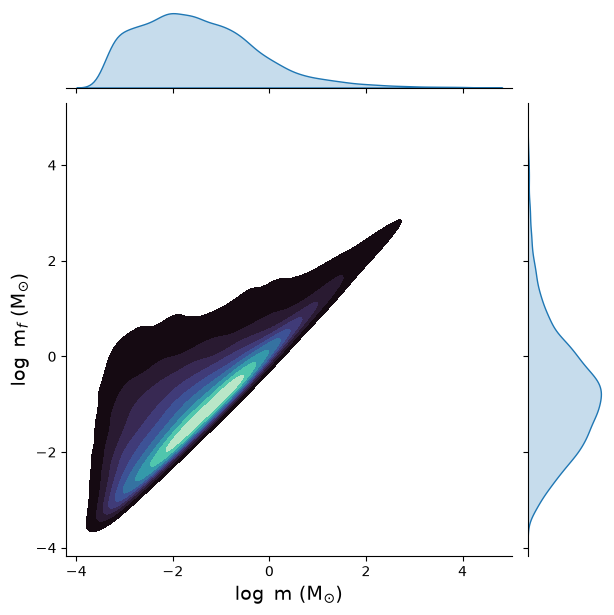

In [5]:
g = sne.jointplot(x = np.log(m_arr), y = np.log(mf_arr), kind='kde', fill=True, cmap='mako')
g.set_axis_labels(r"$\log$ m (M$_{\odot}$)", r"$\log$ m$_f$ (M$_{\odot}$)", fontsize=14)

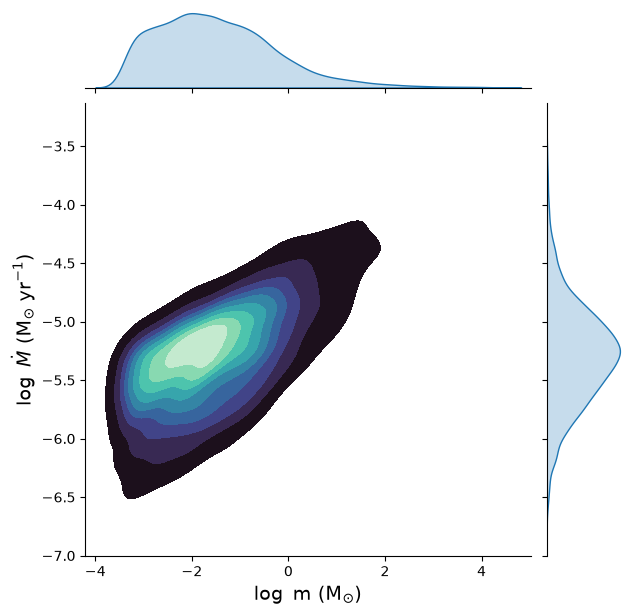

In [6]:
g = sne.jointplot(x = np.log(m_arr), y = np.log10(mdot_arr),  kind='kde', fill=True, cmap='mako')
g.set_axis_labels(r"$\log$ m (M$_{\odot}$)", r"$\log$ $\dot{M}$ (M$_{\odot}$ yr$^{-1}$)", fontsize=14)

In [7]:
#Semi-analytic calculation of psi_p(m), computed directly from plawObj/pmfObj (the same
#objects used for sampling above), so this is a genuine self-consistent check on PhiInvertSample.
def getAnalytic():
    ml, mmax = pmfObj.ml, pmfObj.mmax

    def calcPMF(ML, MU):
        m = np.logspace(np.log10(ML), np.log10(MU), int(1E3))
        PSIM = []
        for mi in m:
            mf = np.logspace(np.log10(max(ML, mi)), np.log10(MU), int(1E3))
            #tacc(m=mf) is singular for tapered accretion (accretion rate -> 0 as m -> mf),
            #so exclude that boundary point, mirroring PhiInvertSample's strict mi < mfi mask.
            mf = mf[mf > mi]
            if len(mf) < 2:
                PSIM.append(0.0)
                continue
            integrand = pmfObj.IMFArr(mf)*plawObj.tacc(mi, mf)
            PSIM.append(sint.trapezoid(integrand/mf, x=mf))
        PSIM = np.array(PSIM)/plawObj.tmav(pmfObj.IMF, ML, MU)
        return m, PSIM
    return calcPMF(ml, mmax)
marr, PSIM = getAnalytic()
integl = sint.trapezoid(PSIM, x=np.log(marr))

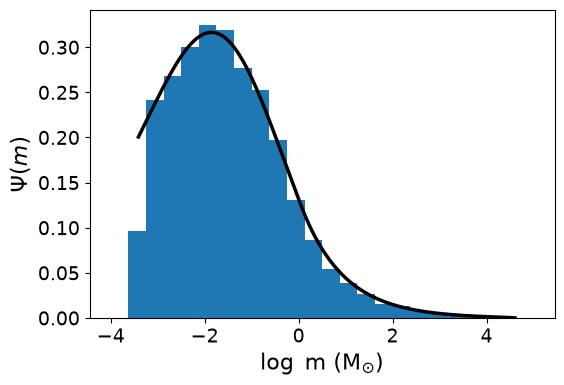

In [8]:
#Plot the distribution and the analytic, to check the sampling behavior
fig = plt.figure(figsize=(6,4))
ax = fig.add_subplot(111)
ax.hist(np.log(m_arr), bins=np.linspace(-4, 5, 25), density=True, log=False)
ax.plot(np.log(marr), (1./integl)*PSIM, 'k-', lw=2.5)
ax.set_xlabel(r"$\log$ m (M$_{\odot}$)", fontsize=16)
ax.set_ylabel(r"$\Psi(m)$", fontsize=16)
ax.tick_params(which='both', axis='both', labelsize=14)
plt.show()

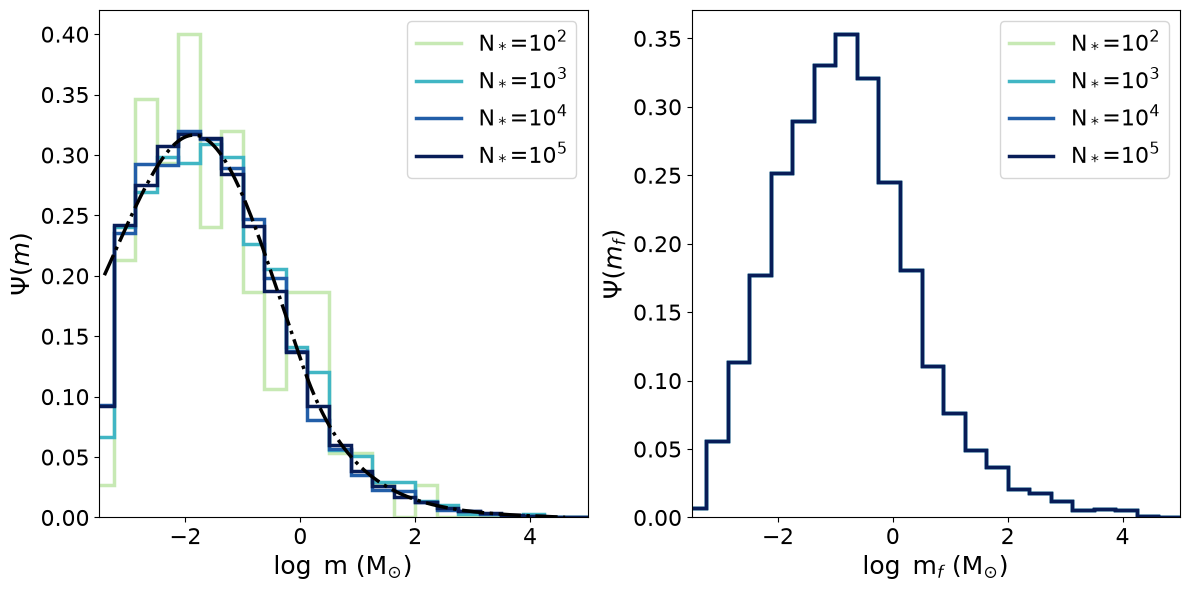

In [10]:
#This goes through and computes a few sampling to check convergence
NC_arr = [100, 1000, 10000, 100000]
labels = [r"$10^2$", r"$10^3$", r"$10^4$", r"$10^5$"]
colors = ['#c7e9b4', '#41b6c4', '#225ea8', '#081d58']

fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(121)
ax2= fig.add_subplot(122)
for (i, NCi) in enumerate(NC_arr):
    mi_arr, mfi_arr = pmfObj.PhiInvertSample(N=int(NCi))
    ax.stairs(*np.histogram(np.log(mi_arr), bins=np.linspace(-4, 5, 25), density=True), fill=False,
       alpha=1.0, edgecolor=colors[i], lw=2.5, label=f"N$_*$={labels[i]}")
    ax2.stairs(*np.histogram(np.log(mf_arr), bins=np.linspace(-4, 5, 25), density=True), fill=False,
       alpha=1.0, edgecolor=colors[i], lw=2.5, label=f"N$_*$={labels[i]}")
    
ax.plot(np.log(marr), (1./integl)*PSIM, 'k-.', lw=2.5, zorder = 999)
ax.set_xlabel(r"$\log$ m (M$_{\odot}$)", fontsize=18)
ax.set_ylabel(r"$\Psi(m)$", fontsize=18)
ax.legend(loc='best', fontsize=16)
ax.tick_params(which='both', axis='both', labelsize=16)
ax.set_xlim(-3.5, 5)

ax2.set_xlabel(r"$\log$ m$_f$ (M$_{\odot}$)", fontsize=18)
ax2.set_ylabel(r"$\Psi(m_f)$", fontsize=18)
ax2.legend(loc='best', fontsize=16)
ax2.tick_params(which='both', axis='both', labelsize=16)
ax2.set_xlim(-3.5, 5)

plt.tight_layout()
plt.show()

In [11]:
#Example: statistics of a cluster-integrated quantity (e.g. protostellar jet power),
#comparing a manual implementation against the built-in synthesisClusterStatistic.

#Illustrative constants/prefactors for a simple jet-power estimate, P_jet ~ f_k*f_w*Mdot*v_esc
G = 6.674e-8              #cm^3 g^-1 s^-2
MSUN = 1.989e33            #g
RSUN = 6.957e10            #cm
Mdotyr_gs = MSUN/3.156e7   #Msun/yr -> g/s
fk, fw = 0.3, 0.3          #fiducial jet efficiency factors

def funcJetPower(m, mf, mdot):
    #Per-protostar jet power, elementwise in m (Msun), mf (Msun), mdot (Msun/yr)
    return fk*fw*(mdot*Mdotyr_gs)*np.sqrt(G*(m*MSUN)/(2.5*RSUN))

NC_test = 200      #protostars per cluster
Nsamp_test = 500   #number of cluster draws

In [ ]:
#Manual approach: oversample once, then chunk into clusters of NC_test stars and sum
#(this is the pattern used before synthesisClusterStatistic existed)
np.random.seed(0)
mbig_arr, mfbig_arr = pmfObj.PhiInvertSample(N=int(NC_test*Nsamp_test))
mdotbig_arr = plawObj.acc(mbig_arr, mfbig_arr)
pjet_arr = funcJetPower(mbig_arr, mfbig_arr, mdotbig_arr)

sumArr_manual = []
j = 0
while j + NC_test <= len(pjet_arr):
    sumArr_manual.append(np.sum(pjet_arr[j:j+NC_test]))
    j += NC_test
sumArr_manual = np.array(sumArr_manual)

mean_manual, std_manual = np.mean(sumArr_manual), np.std(sumArr_manual)
print(f"Manual:    <P_jet> = {mean_manual:.3e}, std(P_jet) = {std_manual:.3e}, over {len(sumArr_manual)} clusters")

Manual:    <P_jet> = 4.091e+29, std(P_jet) = 1.720e+29, over 500 clusters


In [13]:
#Built-in approach: the same statistic, in a single call
np.random.seed(0)
mean_builtin, std_builtin = pmfObj.synthesisClusterStatistic(
    Nproto=NC_test, Nsamp=Nsamp_test, funcQuantity=funcJetPower
)
print(f"Built-in:  <P_jet> = {mean_builtin:.3e}, std(P_jet) = {std_builtin:.3e}, over {Nsamp_test} clusters")

Built-in:  <P_jet> = 4.091e+29, std(P_jet) = 1.720e+29, over 500 clusters


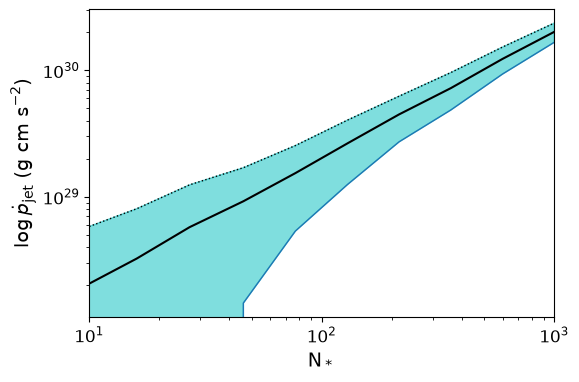

In [ ]:
#synthesisClusterStatistic also accepts an array of cluster sizes directly (with Nsamp=None
#defaulting to max(10, 1E5/Nproto) per size), replacing what used to be an outer loop over
#NC_arr with manual re-sampling and file writing at each step.
NC_arr = np.logspace(1, 3, 10).astype(int)
mean_arr, std_arr = pmfObj.synthesisClusterStatistic(Nproto=NC_arr, funcQuantity=funcJetPower)

fig = plt.figure(figsize=(6,4))
ax = fig.add_subplot(111)
ax.plot(NC_arr, mean_arr, 'k-', lw=1.5)
ax.fill_between(NC_arr, mean_arr - std_arr, mean_arr + std_arr, color='c', alpha=0.5)
ax.plot(NC_arr, mean_arr - std_arr, NC_arr, mean_arr + std_arr, 'k:', lw=1.0)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(NC_arr[0], NC_arr[-1])
ax.set_xlabel(r"N$_*$", fontsize=14)
ax.set_ylabel(r"$\dot{p}_{\rm jet}$ (g cm s$^{-2}$)", fontsize=14)
ax.tick_params(which='both', axis='both', labelsize=12)
plt.show()